Algoritmos Metaheuristicos  
Tarea 6 - Organizacion de Horarios (UCTP)  
Autor: Ing. Daniel Eduardo González Alvarado  
Profesor: Dr. Marco Aceves

# Bin Packing Problem

Se busca minimizar la funcion:  

$z(y)=\sum_{i=1}^{n}(y_i)$  

La cual representa el numero de contenedores utilizados y esta sujeta a:  


$\left[ \sum_{j=1}^{n} p_j x_{ij} \right] \leq c_i y_i $
$\qquad i \in \mathbb{N} = \{1,2,\dots,n\}$

$\sum_{i=1}^{n} x_{ij} = 1 $
$\qquad j \in \mathbb{N}$


Donde:

$
y_i = \begin{cases}
1 & \text{Si se usa el contenedor } i \\
0 & \text{Cualquier otro caso}
\end{cases}
$

$
x_{ij} =\begin{cases}
1 & \text{Objeto } j \text{ se asigna al contenedor } i \\
0 & \text{Cualquier otro caso}
\end{cases}
$

Para este problema tenemos los siguientes contenedores nombrados de la A a la E y 7 paquetes de diferentes tamaños:

![Bin Packin Problem](\Reportes\Bin_Packing\rsc\img\intro\Bin_packing.png)

Existen diferentes formas de organizar los paquetes en los contenedores por ejemplo:  

![Ejemplos](\Reportes\Bin_Packing\rsc\img\intro\ejemplos.png)  


# Importar Librerias

In [1]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from collections import defaultdict

# Consideraciones Iniciales

In [2]:
# Datos Caja de tráiler

ANCHO_TRAILER = 2.4      # m
LARGO_TRAILER = 12.0     # m
ANCHO_CAJA = 0.8         # m # cada paquete ocupa 0.8 m de ancho

# Columnas que caben a lo ancho (cada una es un "contenedor" 1D)
NUM_COLUMNAS = int(ANCHO_TRAILER / ANCHO_CAJA)   # = 3

# Capacidad de cada contenedor (columna)
CAP = LARGO_TRAILER      # 12 m

## Paquetes

In [3]:
# Tipos de cajas disponibles (en metros de largo)
TIPOS_CAJA = [2, 3, 5, 6, 8]

# Num. de paquetes (≤ 1000 por capacidad logística)
n_paquetes = 1000

# Generar conjunto de paquetes aleatorios
random.seed(42)
paq = [random.choice(TIPOS_CAJA) for _ in range(n_paquetes)]

print("Número de paquetes:", n_paquetes)
print("Paquetes (tamaños):", paq[:20], "...")


Número de paquetes: 1000
Paquetes (tamaños): [2, 2, 5, 3, 3, 3, 2, 8, 2, 8, 6, 2, 2, 2, 3, 3, 8, 8, 2, 8] ...


## Contenedores

In [4]:
suma_paq = sum(paq)
min_columnas = math.ceil(suma_paq / CAP)

factor_capacidad = 1.2
n_columnas = int(math.ceil(factor_capacidad * min_columnas))

if n_columnas % 3 != 0:
    n_columnas += 3 - (n_columnas % 3)

contenedores = []
for col_idx in range(n_columnas):
    cont = col_idx // 3 + 1
    col = col_idx % 3 + 1
    contenedores.append(f"Cont_{cont}_Col_{col}")

n_contenedores = len(contenedores)

print("Suma paquetes:", suma_paq)
print("Mín columnas necesarias:", min_columnas)
print("Columnas usadas en ACO:", n_columnas)
print("Capacidad total:", n_columnas * CAP)


Suma paquetes: 4802
Mín columnas necesarias: 401
Columnas usadas en ACO: 483
Capacidad total: 5796.0


# Evaluar Aptitud

In [5]:
def eval_sol(solucion):
    carga = [0] * n_contenedores
    for i, cont in enumerate(solucion):
        carga[cont] += paq[i]
        if carga[cont] > CAP:
            return 1e-6, carga
    
    usados = sum(1 for c in carga if c > 0)
    desperdicio = max(0, usados * CAP - sum(paq))
    costo = (usados + 0.1 * desperdicio) / n_paquetes
    fitness = 1.0 / (1.0 + costo)
    
    return fitness, carga

## Calcular Contenedores

In [6]:
def trailers_nece(asignacion, columnas_por_trailer=3):
    # Columnas usadas (~ 1, 2 o 3)
    columnas_usadas = len(set(asignacion))
    
    # Num. trailers: 3 columnas = un trailer
    trailers = math.ceil(columnas_usadas / columnas_por_trailer)
    
    return columnas_usadas, trailers

# Ant Colony

### Inicializar las Feromonas

In [7]:

alpha = 1.0     # importancia de la feromona
beta = 2.0      # importancia de la heurística
rho = 0.5       # tasa de evaporación
Q = 1.0         # cantidad de feromona depositada


In [8]:
def heuristica(paq_idx, cont_idx, carga_actual):
    size = paq[paq_idx]
    carga_cont = carga_actual[cont_idx]
    
    if carga_cont + size > CAP:
        return 0.0
    
    restante = CAP - (carga_cont + size)
    
    return 1.0 / (1.0 + restante)

### Camino

In [9]:
def construir_solucion(tau, alpha, beta):
    carga = [0] * n_contenedores
    solucion = [None] * n_paquetes
    
    orden = np.random.permutation(n_paquetes)
    
    for j in orden:
        atractividades = []
        for k in range(n_contenedores):
            eta = heuristica(j, k, carga)
            t = tau[j, k] ** alpha
            a = t * (eta ** beta)
            atractividades.append(a)
        
        atractividades = np.array(atractividades)
        total = atractividades.sum()
        if total == 0:
            return None
        
        probs = atractividades / total

        cont_elegido = np.random.choice(range(n_contenedores), p=probs)

        solucion[j] = cont_elegido
        carga[cont_elegido] += paq[j]
    
    return solucion

# Metricas

In [10]:
def metricas():
    tau = np.ones((n_paquetes, n_contenedores))
    mejor_solucion_global = None
    mejor_fitness_global = -1
    mejor_carga_global = None
    
    # Historial
    hist_mejor = []
    hist_prom = []
    
    return tau, mejor_solucion_global, mejor_fitness_global, mejor_carga_global, hist_mejor, hist_prom

# Algoritmo Principal

In [11]:
def ant_colony(n_hormigas, n_iteraciones):
    (tau,
     mejor_solucion_global,
     mejor_fitness_global,
     mejor_carga_global,
     hist_mejor,
     hist_prom) = metricas()

    for it in range(n_iteraciones):
        soluciones = []
        fitnesses = []
        
        for _ in range(n_hormigas):
            sol = construir_solucion(tau, alpha, beta)
            if sol is None:
                fit, carga = 1e-6, [0] * n_contenedores
            else:
                fit, carga = eval_sol(sol)
            soluciones.append((sol, carga))
            fitnesses.append(fit)
        
        fitnesses = np.array(fitnesses)
        
        idx_best = int(np.argmax(fitnesses))
        sol_best, carga_best = soluciones[idx_best]
        fit_best = float(fitnesses[idx_best])
        
        fit_prom = float(fitnesses.mean())
        
        hist_mejor.append(fit_best)
        hist_prom.append(fit_prom)
        
        if sol_best is not None and fit_best > mejor_fitness_global:
            mejor_fitness_global = fit_best
            mejor_solucion_global = sol_best
            mejor_carga_global = carga_best
        
        tau = (1 - rho) * tau
        
        if sol_best is not None:
            for j, cont in enumerate(sol_best):
                tau[j, cont] += Q * fit_best
        
        if (it + 1) % 10 == 0 or it == 0:
            print(
                f"Iteración {it+1} | "
                f"Mejor fitness iteración: {fit_best:.4f} | "
                f"Promedio: {fit_prom:.4f} | "
                f"Mejor global: {mejor_fitness_global:.4f}"
            )
    
    return mejor_solucion_global, mejor_fitness_global, mejor_carga_global, tau, hist_mejor, hist_prom

# Ejecucion

In [31]:
(mejor_sol,
 mejor_fit,
 mejor_carga,
 tau_final,
 hist_mejor,
 hist_prom) = ant_colony(n_hormigas=20, n_iteraciones=100)

Iteración 1 | Mejor fitness iteración: 0.6853 | Promedio: 0.6811 | Mejor global: 0.6853
Iteración 10 | Mejor fitness iteración: 0.6802 | Promedio: 0.6744 | Mejor global: 0.6863
Iteración 20 | Mejor fitness iteración: 0.6575 | Promedio: 0.6507 | Mejor global: 0.6863
Iteración 30 | Mejor fitness iteración: 0.6585 | Promedio: 0.6523 | Mejor global: 0.6863
Iteración 40 | Mejor fitness iteración: 0.6623 | Promedio: 0.6571 | Mejor global: 0.6863
Iteración 50 | Mejor fitness iteración: 0.6662 | Promedio: 0.6627 | Mejor global: 0.6863
Iteración 60 | Mejor fitness iteración: 0.6711 | Promedio: 0.6682 | Mejor global: 0.6863
Iteración 70 | Mejor fitness iteración: 0.6761 | Promedio: 0.6737 | Mejor global: 0.6863
Iteración 80 | Mejor fitness iteración: 0.6782 | Promedio: 0.6774 | Mejor global: 0.6863
Iteración 90 | Mejor fitness iteración: 0.6782 | Promedio: 0.6780 | Mejor global: 0.6863
Iteración 100 | Mejor fitness iteración: 0.6782 | Promedio: 0.6782 | Mejor global: 0.6863


In [32]:
# Asignación paquete → contenedor físico/columna
print("\nAsignación (paquete -> contenedor físico/columna):")
for i, bin_idx in enumerate(mejor_sol):
    cont_fis = bin_idx // 3 + 1
    col = bin_idx % 3 + 1
    print(f"Paquete {i} (size={paq[i]}) -> Cont_{cont_fis}_Col_{col}")

# Cargas por columna (solo las que se usaron)
print("\nCargas por columna:")
for bin_idx, c in enumerate(mejor_carga):
    if c > 0:
        cont_fis = bin_idx // 3 + 1
        col = bin_idx % 3 + 1
        print(f"Cont_{cont_fis}_Col_{col}: carga = {c} / {CAP}")


Asignación (paquete -> contenedor físico/columna):
Paquete 0 (size=2) -> Cont_74_Col_1
Paquete 1 (size=2) -> Cont_105_Col_3
Paquete 2 (size=5) -> Cont_85_Col_3
Paquete 3 (size=3) -> Cont_96_Col_3
Paquete 4 (size=3) -> Cont_91_Col_1
Paquete 5 (size=3) -> Cont_44_Col_1
Paquete 6 (size=2) -> Cont_94_Col_3
Paquete 7 (size=8) -> Cont_127_Col_1
Paquete 8 (size=2) -> Cont_10_Col_1
Paquete 9 (size=8) -> Cont_139_Col_1
Paquete 10 (size=6) -> Cont_156_Col_1
Paquete 11 (size=2) -> Cont_89_Col_2
Paquete 12 (size=2) -> Cont_86_Col_1
Paquete 13 (size=2) -> Cont_83_Col_3
Paquete 14 (size=3) -> Cont_80_Col_1
Paquete 15 (size=3) -> Cont_48_Col_3
Paquete 16 (size=8) -> Cont_32_Col_1
Paquete 17 (size=8) -> Cont_115_Col_3
Paquete 18 (size=2) -> Cont_37_Col_1
Paquete 19 (size=8) -> Cont_101_Col_3
Paquete 20 (size=3) -> Cont_148_Col_3
Paquete 21 (size=8) -> Cont_142_Col_3
Paquete 22 (size=6) -> Cont_135_Col_1
Paquete 23 (size=3) -> Cont_31_Col_1
Paquete 24 (size=6) -> Cont_119_Col_2
Paquete 25 (size=8) -> 

In [33]:
# Agrupar cargas por contenedor físico
from collections import defaultdict
carga_por_cont_fisico = defaultdict(float)

for bin_idx, c in enumerate(mejor_carga):
    if c > 0:
        cont_fis = bin_idx // 3
        carga_por_cont_fisico[cont_fis] += c

# Mostrar cargas globales por contenedor físico
print("\nCargas por contenedor físico:")
for cont_fis in sorted(carga_por_cont_fisico):
    print(f"Contenedor {cont_fis+1}: carga total = {carga_por_cont_fisico[cont_fis]} / {CAP*3}")


Cargas por contenedor físico:
Contenedor 1: carga total = 34.0 / 36.0
Contenedor 2: carga total = 22.0 / 36.0
Contenedor 3: carga total = 34.0 / 36.0
Contenedor 4: carga total = 34.0 / 36.0
Contenedor 5: carga total = 24.0 / 36.0
Contenedor 6: carga total = 23.0 / 36.0
Contenedor 7: carga total = 34.0 / 36.0
Contenedor 8: carga total = 11.0 / 36.0
Contenedor 9: carga total = 33.0 / 36.0
Contenedor 10: carga total = 34.0 / 36.0
Contenedor 11: carga total = 35.0 / 36.0
Contenedor 12: carga total = 11.0 / 36.0
Contenedor 13: carga total = 24.0 / 36.0
Contenedor 14: carga total = 35.0 / 36.0
Contenedor 15: carga total = 34.0 / 36.0
Contenedor 16: carga total = 35.0 / 36.0
Contenedor 17: carga total = 23.0 / 36.0
Contenedor 18: carga total = 34.0 / 36.0
Contenedor 19: carga total = 35.0 / 36.0
Contenedor 20: carga total = 35.0 / 36.0
Contenedor 21: carga total = 35.0 / 36.0
Contenedor 22: carga total = 34.0 / 36.0
Contenedor 23: carga total = 24.0 / 36.0
Contenedor 24: carga total = 36.0 /

In [34]:
# Número final de contenedores físicos usados
num_cont_fis = len(carga_por_cont_fisico)
print("\nContenedores físicos usados:", num_cont_fis)

print("\nMejor fitness global:", mejor_fit)


Contenedores físicos usados: 161

Mejor fitness global: 0.6863417982155113


# Graficas

## Fitness vs Iteracion

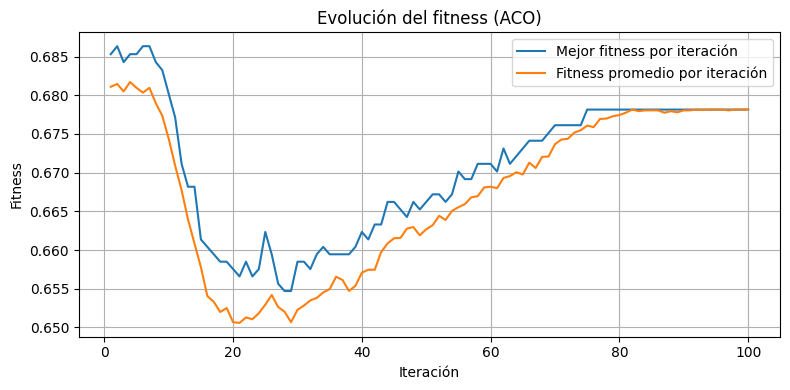

In [35]:
import matplotlib.pyplot as plt

iteraciones = range(1, len(hist_mejor) + 1)

plt.figure(figsize=(8, 4))
plt.plot(iteraciones, hist_mejor, label="Mejor fitness por iteración")
plt.plot(iteraciones, hist_prom, label="Fitness promedio por iteración")
plt.xlabel("Iteración")
plt.ylabel("Fitness")
plt.title("Evolución del fitness (ACO)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Carga por Contenedor

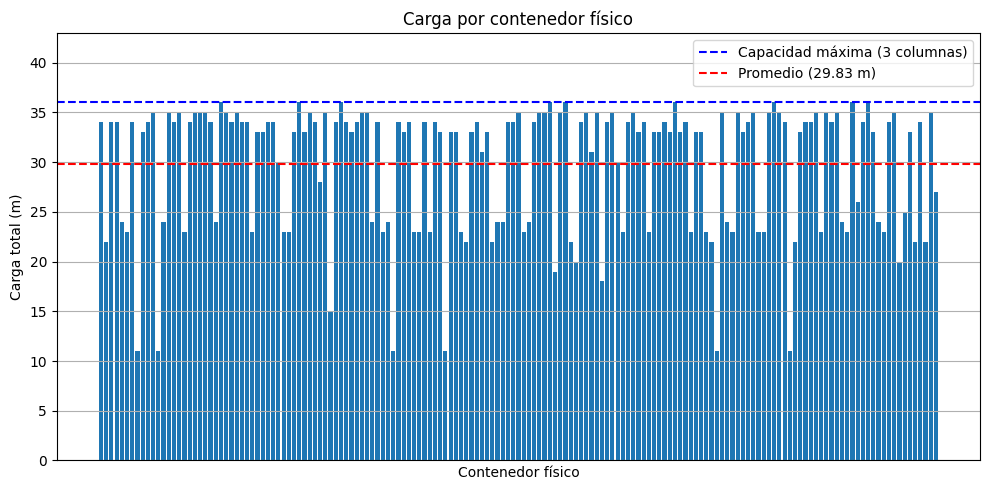

In [36]:
ids_cont = sorted(carga_por_cont_fisico.keys())
valores = [carga_por_cont_fisico[i] for i in ids_cont]

promedio_carga_cont = np.mean(valores)

plt.figure(figsize=(10, 5))
plt.bar(range(len(ids_cont)), valores)

plt.axhline(3 * CAP, linestyle="--", color="blue", label="Capacidad máxima (3 columnas)")

# promedio de cargas
plt.axhline(promedio_carga_cont, linestyle="--", color="red", linewidth=1.5,
            label=f"Promedio ({promedio_carga_cont:.2f} m)")

plt.xlabel("Contenedor físico")
plt.ylabel("Carga total (m)")
plt.title("Carga por contenedor físico")

plt.legend()

plt.ylim(0, max(valores) + 7)
plt.xticks([])

plt.grid(axis="y")
plt.tight_layout()
plt.show()


## Carga por Bin

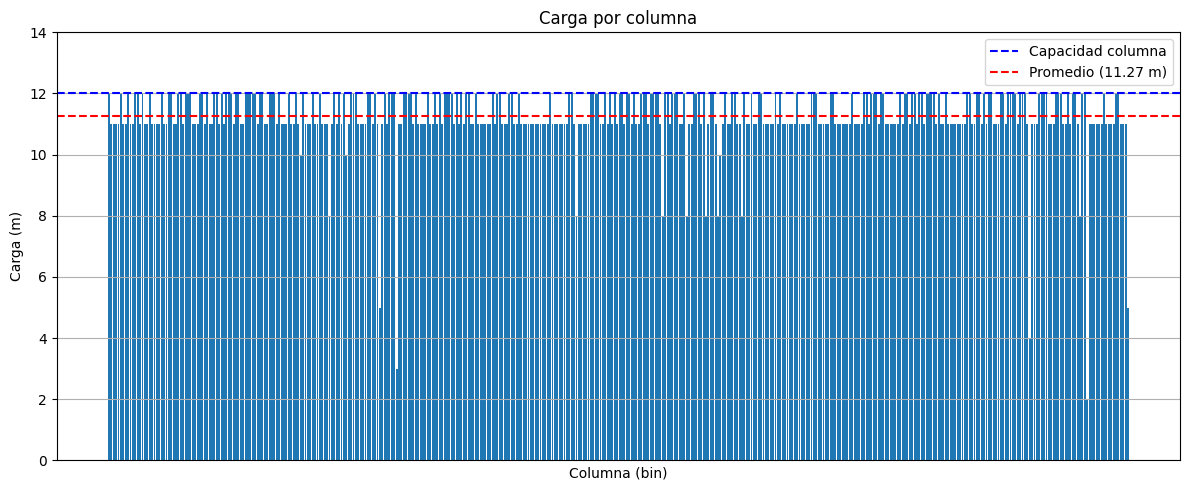

In [37]:
cols_usadas = [(idx, c) for idx, c in enumerate(mejor_carga) if c > 0]
valores_cols = [c for _, c in cols_usadas]

promedio_carga = np.mean(valores_cols)

plt.figure(figsize=(12, 5))
plt.bar(range(len(cols_usadas)), valores_cols)

# Línea de capacidad máxima por columna
plt.axhline(CAP, linestyle="--", color="blue", label="Capacidad columna")

# Línea roja punteada del promedio
plt.axhline(promedio_carga, linestyle="--", color="red", linewidth=1.5,
            label=f"Promedio ({promedio_carga:.2f} m)")

plt.xlabel("Columna (bin)")
plt.ylabel("Carga (m)")
plt.title("Carga por columna")

plt.legend()

plt.ylim(0, max(valores_cols) + 2)
plt.xticks([])

plt.grid(axis="y")
plt.tight_layout()
plt.show()
